# Avance 5 Final Model

### Integrantes:

- **A01794940** José de Jesús Peña Rodríguez.  
- **A01283104** Kevin Dueñas Aguirre.  
- **A01794191** Juan Antonio Chiñas Mata.

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
import importlib
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
warnings.filterwarnings("ignore")
CSV_PATH = "Datos_Imgenes.csv"

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/proj_int/Datos_Imgenes.csv")

In [ ]:
def col_filter(input_df, col_to_filt, filt):
    filtered_df = input_df[input_df[col_to_filt] == filt]
    return filtered_df

In [ ]:
def agg_graph(X_values, labels, graph_titles):
    num_rows = 1
    num_cols = 3


    num_plots = len(X_values)
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(20,5))
    axs = axs.flatten()

    for i, data in enumerate(X_values):
        axs[i].scatter(data[:,0], data[:,1], c=labels[i],cmap="viridis", marker="o")
        axs[i].set_title(graph_titles[i])

    plt.show()

## Data Preprocessing  
Based on a preliminary session with our tutor, we identified several columns that either lacked relevant information or contained redundant data already present in other columns. Consequently, we decided to remove the following columns:  

- `index`  
- `date`  
- `page`  
- `TotalPages`  
- `ModelApplied`  
- `Details`  
- `ModelReported`  

## Project Objective  
For this project, it was explicitly required to develop a solution and analysis to identify groups of documents acquired by different machine learning models.  

### Machine Learning Models  
The models involved in this process are:  

- `Model`  
- `Estado_cuenta`  
- `Recibo_nomina`  
- `INE`  
- `Comprobante_domicilio`  
- `Carta_libranza`

In [ ]:
columns_to_delete = ["Index", "Date", "Page", "TotalPages","ModelApplied", "PagesProcessed", "ConfR", "ConfA", "ConfW","Details","ModelReported","DocType"]
df = df.drop(columns=columns_to_delete, axis=1)

# Creating a filter on Model column

## Data Filtering and Preparation  

In the following cells, we will apply filters to our base dataframe `df`, to extract a new dataframe called `models`.  

The `models` dataframe will allow us to apply further filtering and generate new dataframes, each containing the necessary information for clustering.  


In [ ]:
models = df["Model"].value_counts()
models

,count
Model,
estado_cuenta,34140
recibo_nomina,10193
ine,9346
comprobante_domicilio,5780
carta_libranza,3501


## Filtered Dataframes  

By applying filters, we can generate new observations and create specific dataframes based on relevant criteria.  

- **`df_edo_cta`**: This dataframe will contain at least four distinct values in the `ClassId` column: `TXT`, `APP`, `SUC`, and `ATM`.  
- **`df_nom`**: This dataframe will have exactly four distinct values, using `DocType` as the reference column.  
- **`df_ine`**: This dataframe will contain only two distinct values, taking `DocType` as the reference column.  
- **`df_addy`**: This dataframe will include six different values, using `DocType` as the reference column.  
- **`df_lib`**: This dataframe will include six different values, using `DocType` as the reference column.  



## Displaying all diferent values in:
- `estado_cuenta`  
- `recibo_nomina`  
- `ine`  
- `comprobante_domicilio`  
- `carta libranza`

In [ ]:
df_edo_cta = col_filter(df, "Model", "estado_cuenta")
df_nom = col_filter(df, "Model", "recibo_nomina")
df_ine = col_filter(df, "Model", "ine")
df_addy = col_filter(df, "Model", "comprobante_domicilio")
df_lib = col_filter(df, "Model", "carta_libranza")

# PREPROCESING PER MODEL

Since we are clustering based on the model type rather than the document type, we will start by dropping the Model and Classid columns, as all models have already been filtered and are ready for use.

In [ ]:
df_edo_cta.drop(columns=["Model","ClassId"], inplace=True)
df_nom.drop(columns=["Model","ClassId"], inplace=True)
df_ine.drop(columns=["Model","ClassId"], inplace=True)
df_addy.drop(columns=["Model","ClassId"], inplace=True)
df_lib.drop(columns=["Model","ClassId"], inplace=True)

The feature set (X) will be the same for all clustering algorithms. Therefore, we first generate all possible feature pairs and combine them into a single list. This final X will serve as the input for each model we train.

In [ ]:
df_edo_cta.columns

Index(['Fields', 'EmptyFields', 'Sharpness', 'Contrast', 'Clarity',
       'Resolution'],
      dtype='object')

# Definition of max number of clusters

In [ ]:
agg_cluster = AgglomerativeClustering(n_clusters=3)


# Definition of the scaler

In [ ]:
scaler = StandardScaler()

# Model: Estado de Cuenta

Select only Contrast, Clarity and resolution

In [ ]:
#test
x_cols = [[3,4], [3,5], [4,5]]

In [ ]:
X1 = df_edo_cta.iloc[:,x_cols[0]].values # Contrast and Clarity
X2 = df_edo_cta.iloc[:,x_cols[1]].values # Contrast and Resolution
X3 = df_edo_cta.iloc[:,x_cols[2]].values # Clarity and Resolution

Scaling the most valuable variable combinations

In [ ]:
X1_edo_cta = scaler.fit_transform(X1)
X2_edo_cta = scaler.fit_transform(X2)
X3_edo_cta = scaler.fit_transform(X3)

In [ ]:
y1_edo_cta= agg_cluster.fit_predict(X1_edo_cta)


In [ ]:
y2_edo_cta = agg_cluster.fit_predict(X2_edo_cta)


In [ ]:
y3_edo_cta = agg_cluster.fit_predict(X3_edo_cta)

In [ ]:
graph_titles = ["Contrast & Clarity", "Contrast & Resolution", "Clarity & Resolution"]
labels_edo_cta = [y1_edo_cta, y2_edo_cta, y3_edo_cta]
X_edo_cta = [X1_edo_cta, X2_edo_cta, X3_edo_cta]

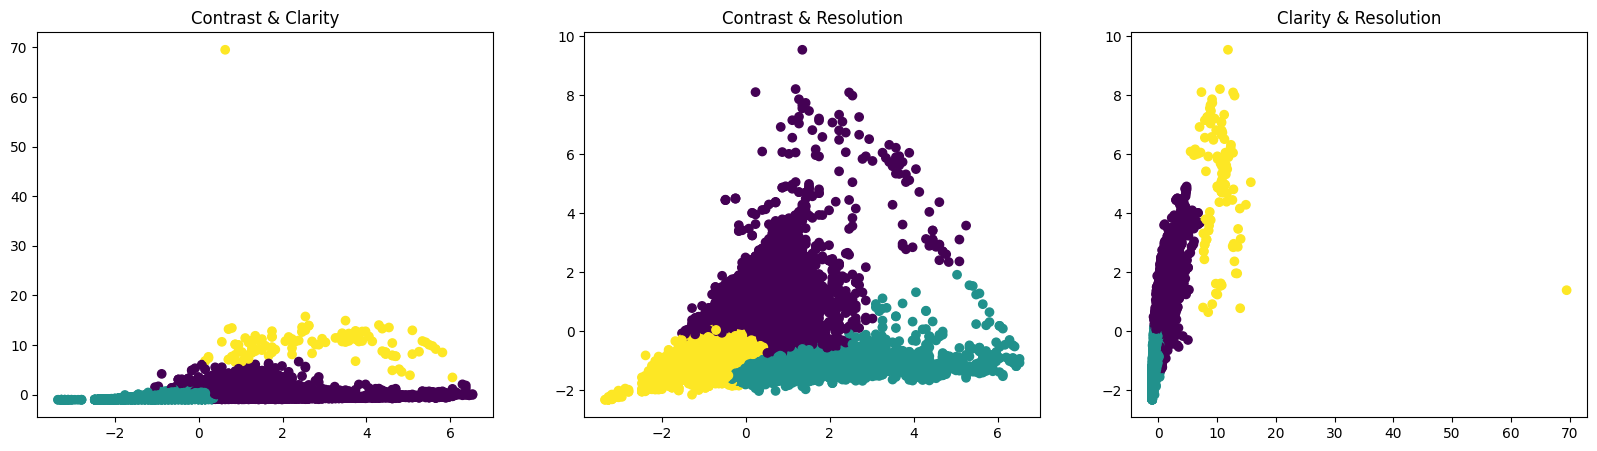

In [ ]:
agg_graph(X_edo_cta, labels_edo_cta, graph_titles)

## Focus on Contrast and Resolution

In [ ]:
temp_df = pd.DataFrame(X2_edo_cta, columns=['Contrast', 'Resolution'])
temp_df['Cluster'] = y2_edo_cta

for cluster_id in temp_df['Cluster'].unique():
    print(f"Cluster {cluster_id}:\n{temp_df[temp_df['Cluster'] == cluster_id]}\n")

Cluster 0:
       Contrast  Resolution  Cluster
0     -0.479966    0.036434        0
1     -0.559570    0.095599        0
2      1.748944    4.804121        0
4      0.714093   -0.648890        0
6     -0.479966    0.066016        0
...         ...         ...      ...
34134 -0.084641    0.205869        0
34136  0.063186    0.748667        0
34137  0.161464    0.856038        0
34138 -0.115868    0.537712        0
34139  0.148920    0.325501        0

[18522 rows x 3 columns]

Cluster 2:
       Contrast  Resolution  Cluster
3     -0.320758   -1.827254        2
7     -0.718777   -0.052313        2
9     -0.718777   -0.022731        2
10    -0.002342   -0.126269        2
11    -0.002342   -0.101617        2
...         ...         ...      ...
34123 -0.873924   -0.212063        2
34125 -0.893370   -0.196167        2
34130 -0.759586   -0.313224        2
34131 -0.791944   -0.356770        2
34132 -1.429964   -1.300924        2

[11402 rows x 3 columns]

Cluster 1:
       Contrast  Resoluti

## Number of EmptyFields

### Assumption: Our categorization is based on the number of EmptyFields detected. Therefore, a low number of EmptyFields indicates that the model is performing well, as it successfully extracts the necessary information with minimal omissions.

### In this step we are going to take a representative data for each cluster

In [ ]:
df_edo_cta.iloc[6]["EmptyFields"] #good perfomance

1.0

In [ ]:
df_edo_cta.iloc[10]["EmptyFields"] #regular perfomance

2.0

In [ ]:
df_edo_cta.iloc[75]["EmptyFields"] #bad perfomance

19.0

In the following code, we create a dictionary `cluster_names` to map cluster IDs to their respective performance categories: 'Good', 'Bad', and 'Regular'. We then identify the unique clusters and assign colors to each cluster using a colormap.

We create a scatter plot to visualize the clusters based on 'Contrast' and 'Resolution'. Each cluster is represented by a different color and labeled accordingly. The plot includes a title, axis labels, and a legend to indicate the performance category of each cluster.

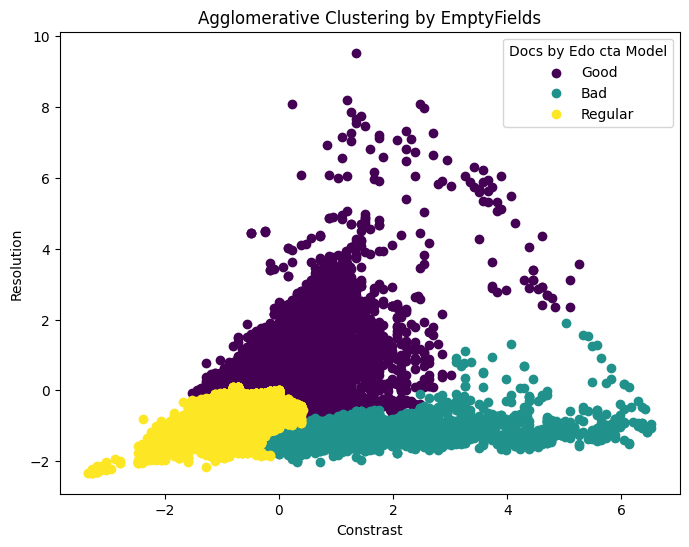

In [ ]:
cluster_names = {0: 'Good', 1: 'Bad', 2: 'Regular'}
unique_clusters = np.unique(y2_edo_cta)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_clusters)))

plt.figure(figsize=(8, 6))


for cluster_id, color in zip(unique_clusters, colors):
    mask = y2_edo_cta == cluster_id
    plt.scatter(X2_edo_cta[mask, 0], X2_edo_cta[mask, 1],
                color=color, label=cluster_names[cluster_id], marker='o')


plt.title('Agglomerative Clustering by EmptyFields')
plt.xlabel('Constrast')
plt.ylabel('Resolution')

plt.legend(title="Docs by Edo cta Model")
plt.show()


# Model: Recibo de Nomina

In this section, we will perform clustering analysis on the `Recibo de Nomina` model, including data preprocessing, scaling, and applying agglomerative clustering. The results will be visualized to understand the clustering patterns based on different feature combinations.

In [ ]:
X1 = df_nom.iloc[:,x_cols[0]].values # Contrast and Clarity
X2 = df_nom.iloc[:,x_cols[1]].values # Contrast and Resolution
X3 = df_nom.iloc[:,x_cols[2]].values # Clarity and Resolution

In [ ]:
X1_nom = scaler.fit_transform(X1)
X2_nom = scaler.fit_transform(X2)
X3_nom = scaler.fit_transform(X3)

In [ ]:
y1_nom = agg_cluster.fit_predict(X1_nom)

In [ ]:
y2_nom = agg_cluster.fit_predict(X2_nom)

In [ ]:
y3_nom = agg_cluster.fit_predict(X3_nom)

In [ ]:
labels_nom = [y1_nom, y2_nom, y3_nom]
X_nom = [X1_nom, X2_nom, X3_nom]

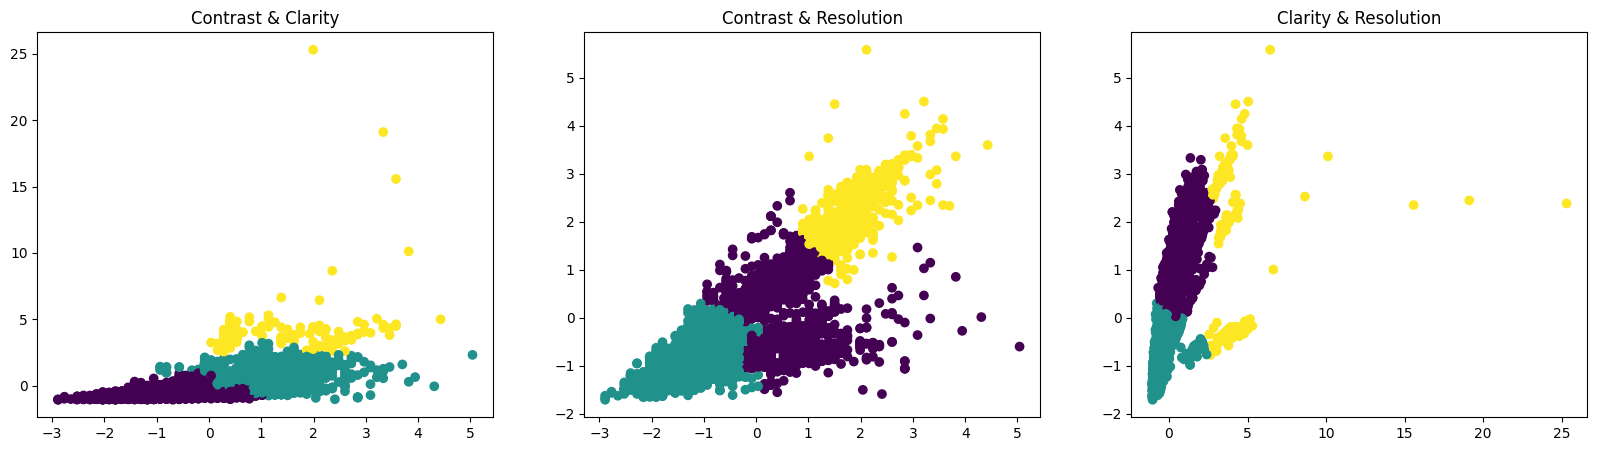

In [ ]:
agg_graph(X_nom, labels_nom, graph_titles)

In [ ]:
temp_df2 = pd.DataFrame(X2_nom, columns=['Contrast', 'Resolution'])
temp_df2['Cluster'] = y2_nom

for cluster_id in temp_df2['Cluster'].unique():
    print(f"Cluster {cluster_id}:\n{temp_df2[temp_df2['Cluster'] == cluster_id]}\n")

Cluster 0:
       Contrast  Resolution  Cluster
0      0.405423    0.723017        0
2     -0.204353    0.406821        0
3     -0.326308    0.158080        0
7     -0.448263    0.183376        0
8      0.771288    1.153044        0
...         ...         ...      ...
10188  0.444543   -0.469596        0
10189  0.405850   -0.491047        0
10190  0.867602   -0.838598        0
10191  0.642846   -0.281643        0
10192  0.562449   -0.391587        0

[5061 rows x 3 columns]

Cluster 1:
       Contrast  Resolution  Cluster
1     -1.179994   -1.127784        1
5     -1.058039   -0.385777        1
6     -0.692174   -0.031638        1
9     -1.179994   -1.077193        1
10    -0.936084   -1.216319        1
...         ...         ...      ...
10175 -1.290135   -1.283858        1
10176 -1.299512   -0.695207        1
10181 -1.560403   -1.352083        1
10185 -1.413470   -0.573461        1
10187 -0.937802   -0.881471        1

[3945 rows x 3 columns]

Cluster 2:
       Contrast  Resolution

In [ ]:
df_nom.iloc[7]["EmptyFields"] #Regular

1.0

In [ ]:
df_nom.iloc[9]["EmptyFields"] # Bad

3.0

In [ ]:
df_nom.iloc[87]["EmptyFields"] # Good

0.0

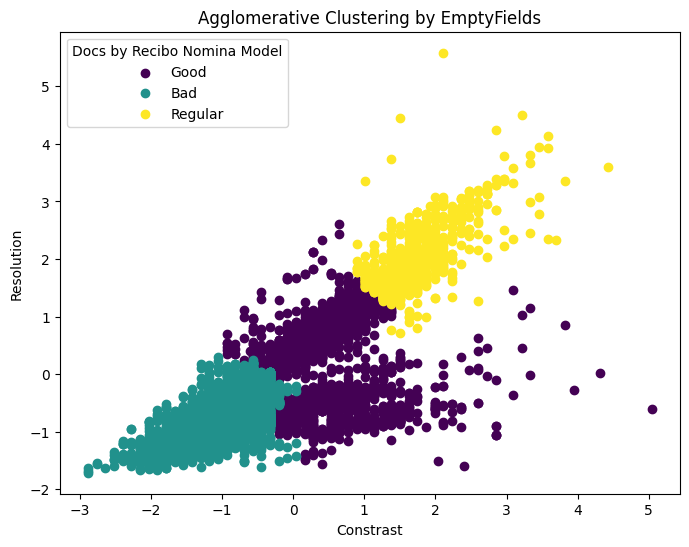

In [ ]:
cluster_names = {0: 'Good', 1: 'Bad', 2: 'Regular'}
unique_clusters = np.unique(y2_nom)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_clusters)))

plt.figure(figsize=(8, 6))

for cluster_id, color in zip(unique_clusters, colors):
    mask = y2_nom == cluster_id
    plt.scatter(X2_nom[mask, 0], X2_nom[mask, 1],
                color=color, label=cluster_names[cluster_id], marker='o')


plt.title('Agglomerative Clustering by EmptyFields')
plt.xlabel('Constrast')
plt.ylabel('Resolution')
plt.legend(title="Docs by Recibo Nomina Model")
plt.show()


# Modelo INE

In this section, we will perform clustering analysis on the `INE` model, including data preprocessing, scaling, and applying agglomerative clustering. The results will be visualized to understand the clustering patterns based on different feature combinations.

In [ ]:
X1 = df_ine.iloc[:,x_cols[0]].values # Contrast and Clarity
X2 = df_ine.iloc[:,x_cols[1]].values # Contrast and Resolution
X3 = df_ine.iloc[:,x_cols[2]].values # Clarity and Resolution

In [ ]:
X1_ine = scaler.fit_transform(X1)
X2_ine = scaler.fit_transform(X2)
X3_ine = scaler.fit_transform(X3)

In [ ]:
y1_ine = agg_cluster.fit_predict(X1_ine)

In [ ]:
y2_ine = agg_cluster.fit_predict(X2_ine)

In [ ]:
y3_ine = agg_cluster.fit_predict(X3_ine)

In [ ]:
labels_ine = [y1_ine, y2_ine, y3_ine]
X_ine = [X1_ine, X2_ine, X3_ine]

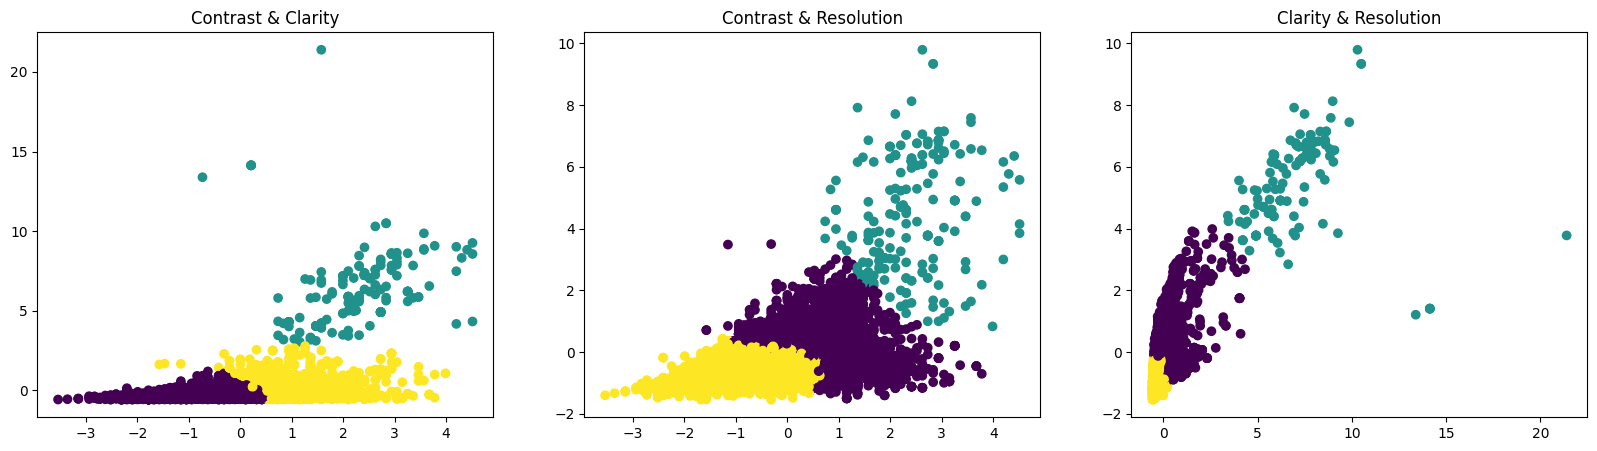

In [ ]:
agg_graph(X_ine, labels_ine, graph_titles)

In [ ]:
temp_df3 = pd.DataFrame(X3_nom, columns=['Contrast', 'Resolution'])
temp_df3['Cluster'] = y3_nom

for cluster_id in temp_df3['Cluster'].unique():
    print(f"Cluster {cluster_id}:\n{temp_df3[temp_df3['Cluster'] == cluster_id]}\n")

Cluster 0:
       Contrast  Resolution  Cluster
0      0.994516    0.723017        0
2      0.625432    0.406821        0
3      0.370501    0.158080        0
7      0.447671    0.183376        0
8      0.728367    1.153044        0
...         ...         ...      ...
10172  0.405838    0.891629        0
10173  1.165248    1.892526        0
10179 -0.044916    0.837155        0
10180 -0.058692    0.794398        0
10186  0.638089    1.462537        0

[3794 rows x 3 columns]

Cluster 1:
       Contrast  Resolution  Cluster
1     -0.506842   -1.127784        1
5     -0.127403   -0.385777        1
6      0.218997   -0.031638        1
9     -0.478612   -1.077193        1
10    -0.595599   -1.216319        1
...         ...         ...      ...
10188 -0.445332   -0.469596        1
10189 -0.453913   -0.491047        1
10190  0.973317   -0.838598        1
10191 -0.234526   -0.281643        1
10192 -0.325799   -0.391587        1

[6138 rows x 3 columns]

Cluster 2:
       Contrast  Resolution

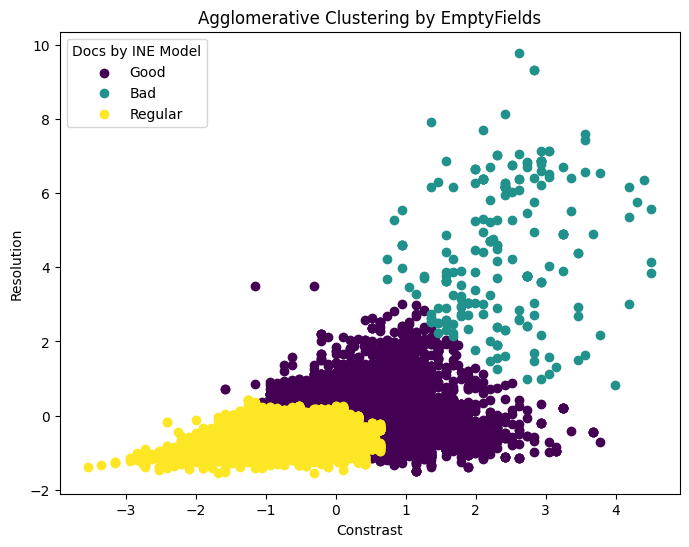

In [ ]:
cluster_names = {0: 'Good', 1: 'Bad', 2: 'Regular'}
unique_clusters = np.unique(y2_ine)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_clusters)))

plt.figure(figsize=(8, 6))

for cluster_id, color in zip(unique_clusters, colors):
    mask = y2_ine == cluster_id
    plt.scatter(X2_ine[mask, 0], X2_ine[mask, 1],
                color=color, label=cluster_names[cluster_id], marker='o')


plt.title('Agglomerative Clustering by EmptyFields')
plt.xlabel('Constrast')
plt.ylabel('Resolution')
plt.legend(title="Docs by INE Model")
plt.show()


# Modelo Comprobante Domicilio

In this section, we will perform clustering analysis on the `Comprobante de Domicilio` model, including data preprocessing, scaling, and applying agglomerative clustering. The results will be visualized to understand the clustering patterns based on different feature combinations.

In [ ]:
X1 = df_addy.iloc[:,x_cols[0]].values # Contrast and Clarity
X2 = df_addy.iloc[:,x_cols[1]].values # Contrast and Resolution
X3 = df_addy.iloc[:,x_cols[2]].values # Clarity and Resolution

In [ ]:
X1_addy = scaler.fit_transform(X1)
X2_addy = scaler.fit_transform(X2)
X3_addy = scaler.fit_transform(X3)

In [ ]:
y1_addy = agg_cluster.fit_predict(X1_addy)

In [ ]:
y2_addy = agg_cluster.fit_predict(X2_addy)

In [ ]:
y3_addy = agg_cluster.fit_predict(X3_addy)

In [ ]:
labels_addy = [y1_addy, y2_addy, y3_addy]
X_addy = [X1_addy, X2_addy, X3_addy]

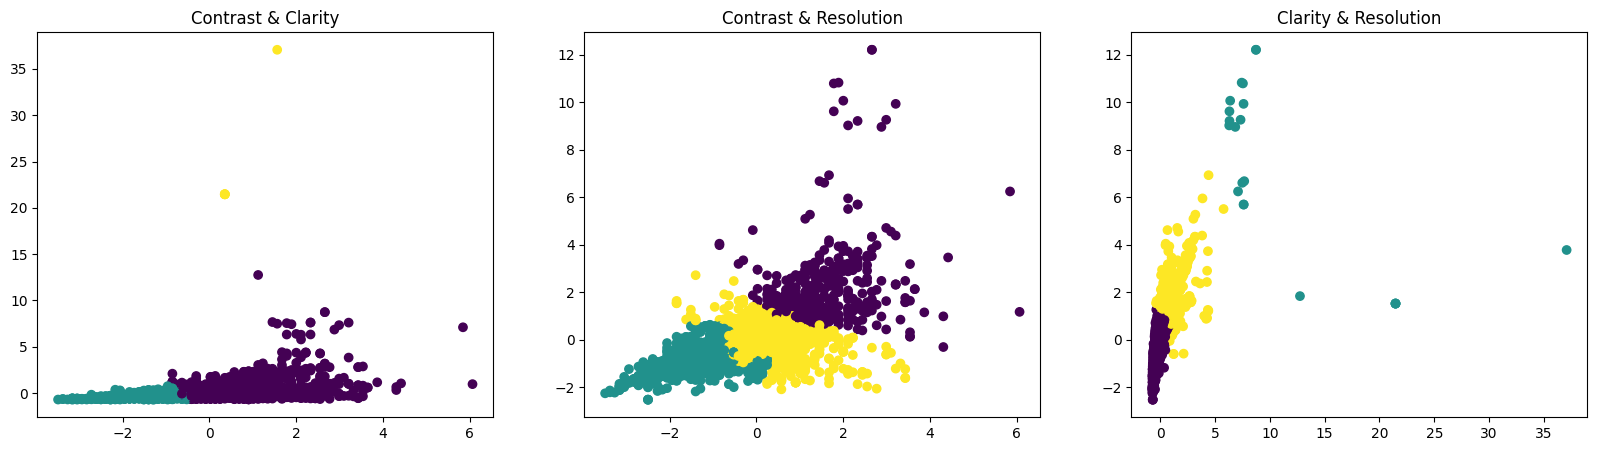

In [ ]:
agg_graph(X_addy, labels_addy, graph_titles)

In [ ]:
temp_df4 = pd.DataFrame(X2_addy, columns=['Contrast', 'Resolution'])
temp_df4['Cluster'] = y2_addy

for cluster_id in temp_df4['Cluster'].unique():
    print(f"Cluster {cluster_id}:\n{temp_df4[temp_df4['Cluster'] == cluster_id]}\n")

Cluster 1:
      Contrast  Resolution  Cluster
0    -1.071600   -1.349936        1
1    -1.730741   -0.812210        1
3    -0.851886   -1.077581        1
5    -0.851886   -1.077581        1
6    -0.851886   -1.077581        1
...        ...         ...      ...
5733 -0.742029   -0.861094        1
5746 -1.071600   -0.134815        1
5756 -1.071600   -1.217250        1
5759 -0.961743    0.186424        1
5765 -1.730741   -0.868078        1

[1477 rows x 3 columns]

Cluster 0:
      Contrast  Resolution  Cluster
2     1.235397    1.576132        0
57    0.905826    1.520265        0
113   1.674825    2.372247        0
124   0.795969    1.457414        0
218   0.686112    1.422496        0
...        ...         ...      ...
5723  0.686112    2.106875        0
5729  3.432536    1.764686        0
5752  1.564968    1.855471        0
5757  1.784682    0.919687        0
5766  2.553680    3.447699        0

[613 rows x 3 columns]

Cluster 2:
      Contrast  Resolution  Cluster
4    -0.302601  

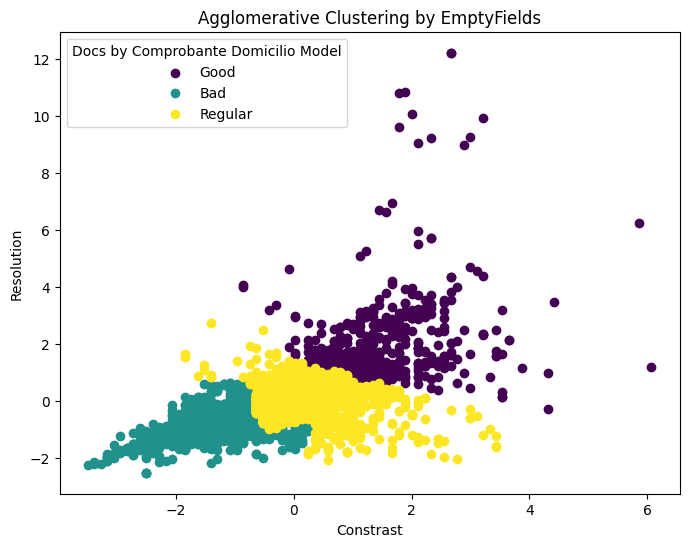

In [ ]:
cluster_names = {0: 'Good', 1: 'Bad', 2: 'Regular'}
unique_clusters = np.unique(y2_addy)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_clusters)))

plt.figure(figsize=(8, 6))

for cluster_id, color in zip(unique_clusters, colors):
    mask = y2_addy == cluster_id
    plt.scatter(X2_addy[mask, 0], X2_addy[mask, 1],
                color=color, label=cluster_names[cluster_id], marker='o')


plt.title('Agglomerative Clustering by EmptyFields')
plt.xlabel('Constrast')
plt.ylabel('Resolution')
plt.legend(title="Docs by Comprobante Domicilio Model")
plt.show()

# Modelo Carta Libranza

This model needs a small number of clusters due to the nature of the data and the specific requirements of the analysis. By reducing the number of clusters, we aim to achieve more meaningful and interpretable groupings, which can help in better understanding the underlying patterns and characteristics of the data. This approach is particularly useful when dealing with homogeneous data or when the goal is to simplify the clustering results for easier interpretation and actionable insights.

## This models needs a small number of clusters.

In [ ]:
agg_cluster = AgglomerativeClustering(n_clusters=2)

In [ ]:
X1 = df_lib.iloc[:,x_cols[0]].values # Contrast and Clarity
X2 = df_lib.iloc[:,x_cols[1]].values # Contrast and Resolution
X3 = df_lib.iloc[:,x_cols[2]].values # Clarity and Resolution

In [ ]:
X1_lib = scaler.fit_transform(X1)
X2_lib = scaler.fit_transform(X2)
X3_lib = scaler.fit_transform(X3)

In [ ]:
y1_lib = agg_cluster.fit_predict(X1_lib)

In [ ]:
y2_lib = agg_cluster.fit_predict(X2_lib)

In [ ]:
y3_lib = agg_cluster.fit_predict(X3_lib)

In [ ]:
labels_lib = [y1_lib, y2_lib, y3_lib]
X_lib = [X1_lib, X2_lib, X3_lib]

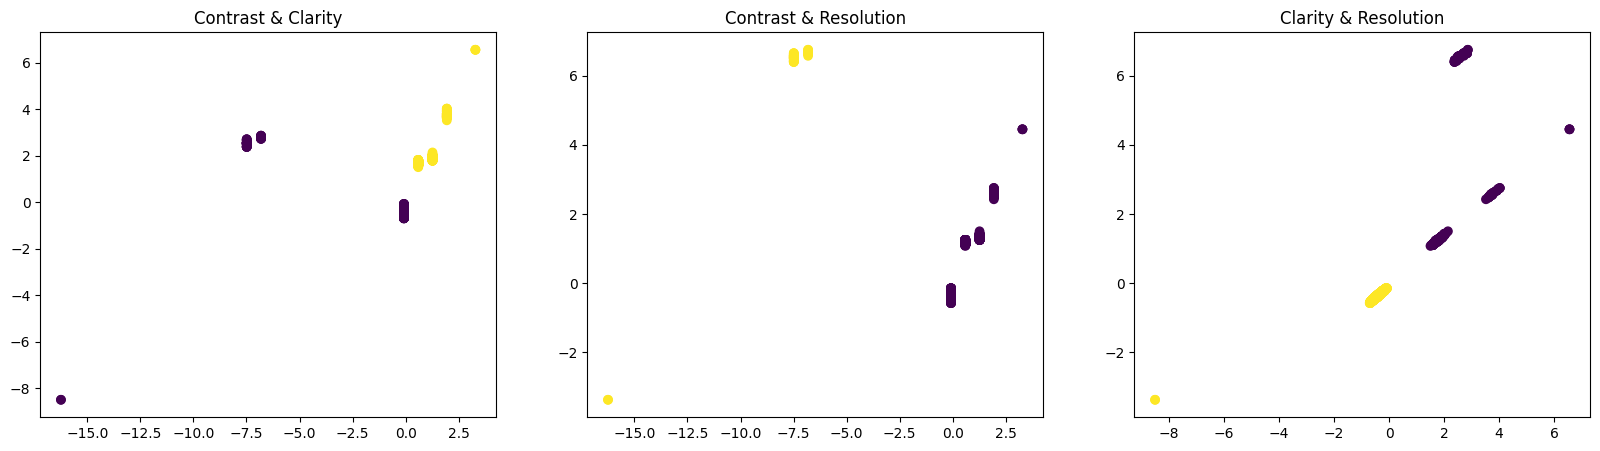

In [ ]:
agg_graph(X_lib, labels_lib, graph_titles)

In [ ]:
temp_df5 = pd.DataFrame(X2_lib, columns=['Contrast', 'Resolution'])
temp_df5['Cluster'] = y2_lib

for cluster_id in temp_df5['Cluster'].unique():
    print(f"Cluster {cluster_id}:\n{temp_df5[temp_df5['Cluster'] == cluster_id]}\n")

Cluster 0:
      Contrast  Resolution  Cluster
0    -0.078696   -0.295614        0
1    -0.078696   -0.295614        0
2    -0.078696   -0.420420        0
3    -0.078696   -0.370498        0
4     1.942196    2.624854        0
...        ...         ...      ...
3496  0.594935    1.227023        0
3497  1.268565    1.326868        0
3498 -0.078696   -0.420420        0
3499 -0.078696   -0.470343        0
3500 -0.078696   -0.470343        0

[3456 rows x 3 columns]

Cluster 1:
       Contrast  Resolution  Cluster
8     -6.815004    6.743461        1
13    -6.815004    6.743461        1
527   -7.488635    6.593694        1
531   -7.488635    6.593694        1
535   -7.488635    6.593694        1
595   -6.815004    6.643616        1
601   -6.815004    6.643616        1
606   -6.815004    6.643616        1
613   -6.815004    6.643616        1
618   -6.815004    6.643616        1
850   -6.815004    6.568732        1
928   -7.488635    6.643616        1
932   -7.488635    6.643616        1
93

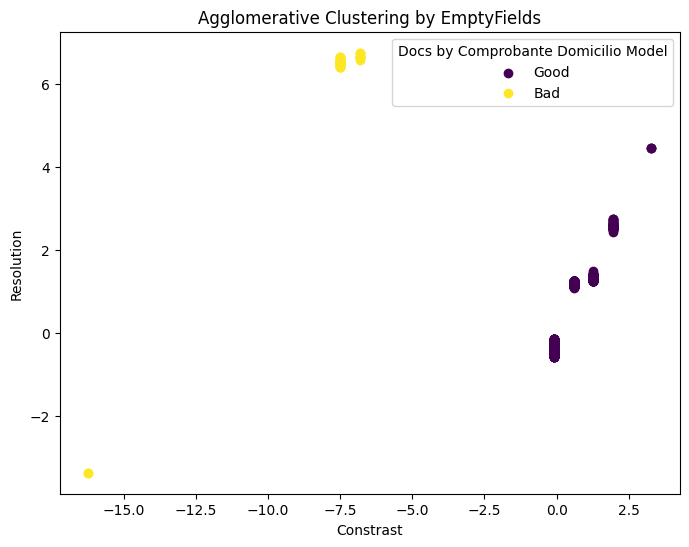

In [ ]:
cluster_names = {0: 'Good', 1: 'Bad', 2: 'Regular'}
unique_clusters = np.unique(y2_lib)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_clusters)))

plt.figure(figsize=(8, 6))

for cluster_id, color in zip(unique_clusters, colors):
    mask = y2_lib == cluster_id
    plt.scatter(X2_lib[mask, 0], X2_lib[mask, 1],
                color=color, label=cluster_names[cluster_id], marker='o')


plt.title('Agglomerative Clustering by EmptyFields')
plt.xlabel('Constrast')
plt.ylabel('Resolution')
plt.legend(title="Docs by Comprobante Domicilio Model")
plt.show()

### Conclusions
In this analysis, we applied agglomerative clustering to various document models (`Estado de Cuenta`, `Recibo de Nomina`, `INE`, `Comprobante de Domicilio`, and `Carta Libranza`). Key features such as Contrast, Clarity, and Resolution were used to identify distinct clusters.

1. **Estado de Cuenta**: Three clusters representing different performance levels based on EmptyFields.
2. **Recibo de Nomina**: Three consistent clusters across different feature combinations.
3. **INE**: Distinct groups identified, aiding in understanding document distribution.
4. **Comprobante de Domicilio**: Clear groupings providing insights into document characteristics.
5. **Carta Libranza**: Two meaningful clusters due to data nature.

Overall, agglomerative clustering effectively identified distinct clusters, aiding in document processing and classification.
